In [2]:
from sklearn.datasets import load_digits
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
digits = load_digits()

In [4]:
pd.DataFrame(digits.data).to_csv("digits_8x8.csv", index=False)

In [5]:
print("Created digits_8x8.csv")

Created digits_8x8.csv


In [6]:
df = pd.read_csv("digits_8x8.csv")

In [7]:

X = df.fillna(0)
X = StandardScaler().fit_transform(X)

In [8]:
wcss = []
for k in range(2, 16):
    wcss.append(KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X).inertia_)


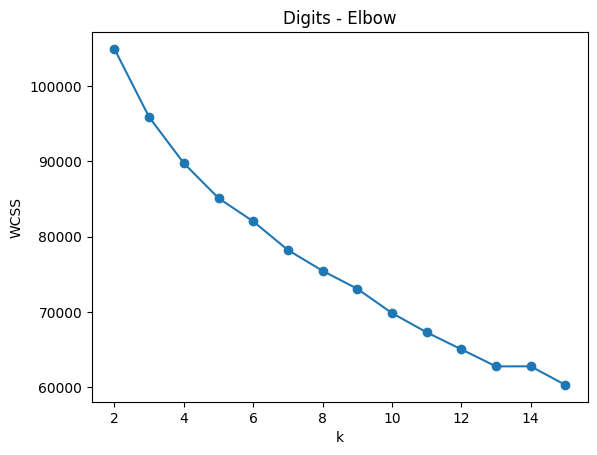

In [9]:
plt.plot(range(2, 16), wcss, marker="o")
plt.title("Digits - Elbow")
plt.xlabel("k"); plt.ylabel("WCSS")
plt.show()

In [10]:
k = 10
model = KMeans(n_clusters=k, random_state=42, n_init="auto")
df["Cluster"] = model.fit_predict(X)

In [11]:
print("Silhouette Score:", silhouette_score(X, df["Cluster"]))

Silhouette Score: 0.13558208876901623


In [12]:
df.to_csv("digits_clustered.csv", index=False)

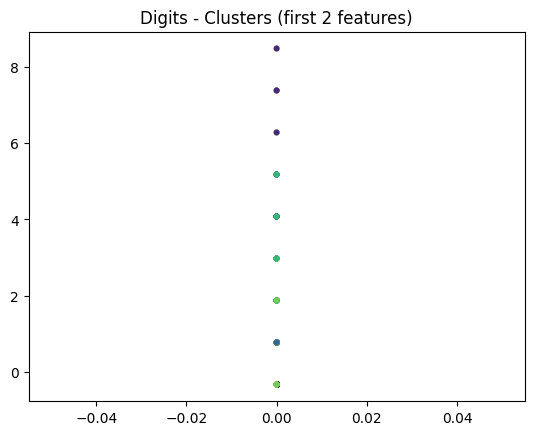

In [13]:
plt.scatter(X[:,0], X[:,1], c=df["Cluster"], s=10)
plt.title("Digits - Clusters (first 2 features)")
plt.show()